In [45]:
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from PIL import Image, ImageEnhance

# For ML Models
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.models import *
from tensorflow.keras.metrics import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
from tensorflow.keras.preprocessing.image import load_img

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
from tqdm import tqdm
import os
import random

In [46]:
train_dir = '/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/'
test_dir = '/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/'

train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    for image in os.listdir(train_dir+label):
        train_paths.append(train_dir+label+'/'+image)
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

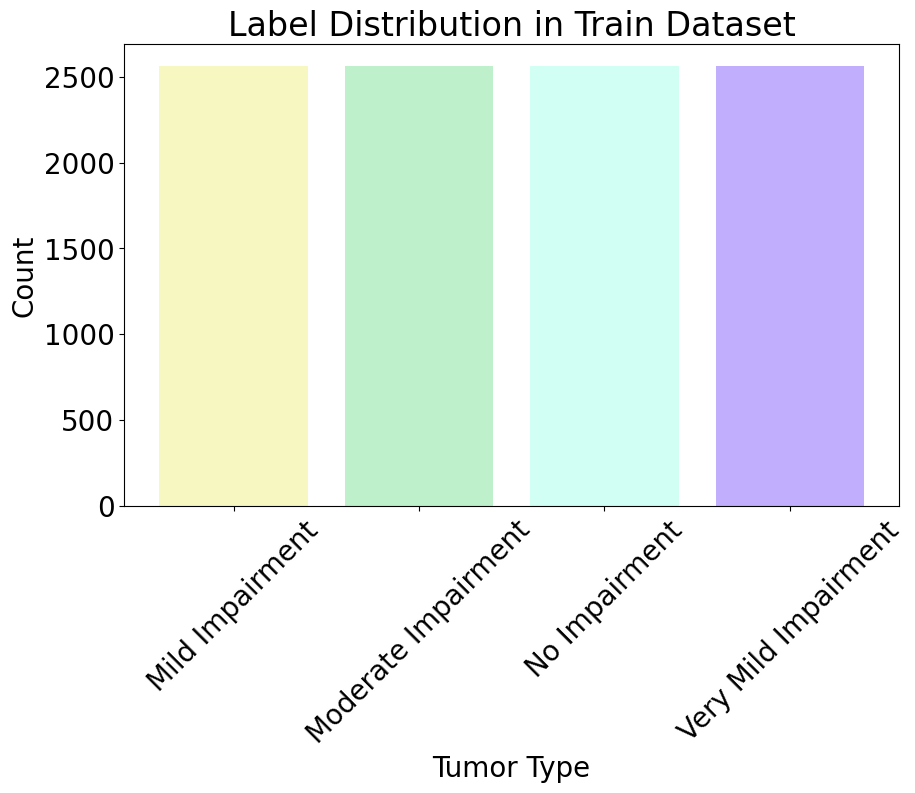

In [47]:
labels = ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
counts = [
    len([x for x in train_labels if x == 'Mild Impairment']),
    len([x for x in train_labels if x == 'Moderate Impairment']),
    len([x for x in train_labels if x == 'No Impairment']),
    len([x for x in train_labels if x == 'Very Mild Impairment'])
]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color=['#F6F7C1', '#BEF0CB', '#D1FFF3', '#C1AEFC'])
plt.title('Label Distribution in Train Dataset')
plt.ylabel('Count')
plt.xlabel('Tumor Type')
plt.xticks(rotation=45)
plt.show()

In [48]:
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    for image in os.listdir(test_dir+label):
        test_paths.append(test_dir+label+'/'+image)
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

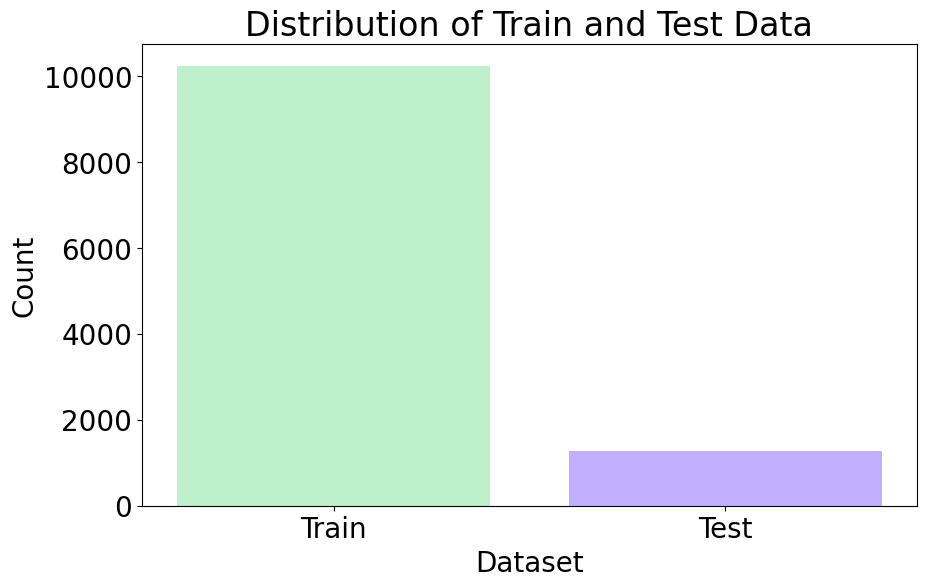

In [49]:
# Counts of train and test datasets
data_labels = ['Train', 'Test']
data_counts = [len(train_labels), len(test_labels)]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(data_labels, data_counts, color=['#BEF0CB', '#C1AEFC'])
plt.title('Distribution of Train and Test Data')
plt.ylabel('Count')
plt.xlabel('Dataset')
plt.show()


In [50]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    image = np.array(image)/255.0
    return image

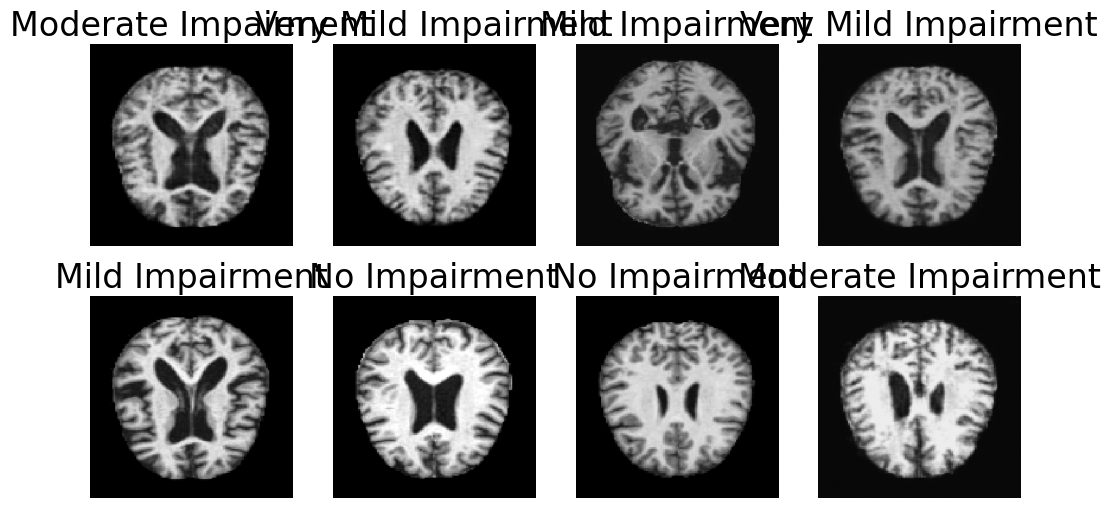

In [51]:
IMAGE_SIZE = 299

def open_images(paths):
    '''
    Given a list of paths to images, this function returns the images as arrays (after augmenting them)
    '''
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE,IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

images = open_images(train_paths[50:59])
labels = train_labels[50:59]
fig = plt.figure(figsize=(12, 6))
for x in range(1, 9):
    fig.add_subplot(2, 4, x)
    plt.axis('off')
    plt.title(labels[x])
    plt.imshow(images[x])
plt.rcParams.update({'font.size': 20})
plt.show()

In [65]:
unique_labels = os.listdir(train_dir)

from tensorflow.keras.utils import to_categorical

def encode_label(labels):
    # Convert labels to integers and then one-hot encode them
    encoded = [unique_labels.index(label) for label in labels]
    return to_categorical(encoded, num_classes=len(unique_labels))


def decode_label(labels):
    unique_labels = list(unique_labels)  # Ensure it’s a list

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for x in range(0, len(paths), batch_size):
            batch_paths = paths[x:x+batch_size]
            batch_images = open_images(batch_paths)  # Load and augment images
            batch_labels = labels[x:x+batch_size]
            batch_labels = encode_label(batch_labels)  # Ensure labels are one-hot encoded
            yield batch_images, batch_labels

In [67]:
def decode_label(unique_labels):
    unique_labels = list(unique_labels) 

In [53]:
unique_labels

['No Impairment',
 'Very Mild Impairment',
 'Moderate Impairment',
 'Mild Impairment']

In [54]:
img_shape = (299, 299, 3)

In [55]:
base_model = Xception(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max')

# Freeze the base model
base_model.trainable = False

# Define the model
inputs = Input(shape=img_shape)
x = base_model(inputs)
x = Flatten()(x)
x = Dropout(rate=0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(rate=0.25)(x)
x = Dense(4, activation='softmax')(x)  # Adjust the number of classes as needed

model = Model(inputs, x)

# Compile the model
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# Summary of the model
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 299, 299, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 2048)                │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

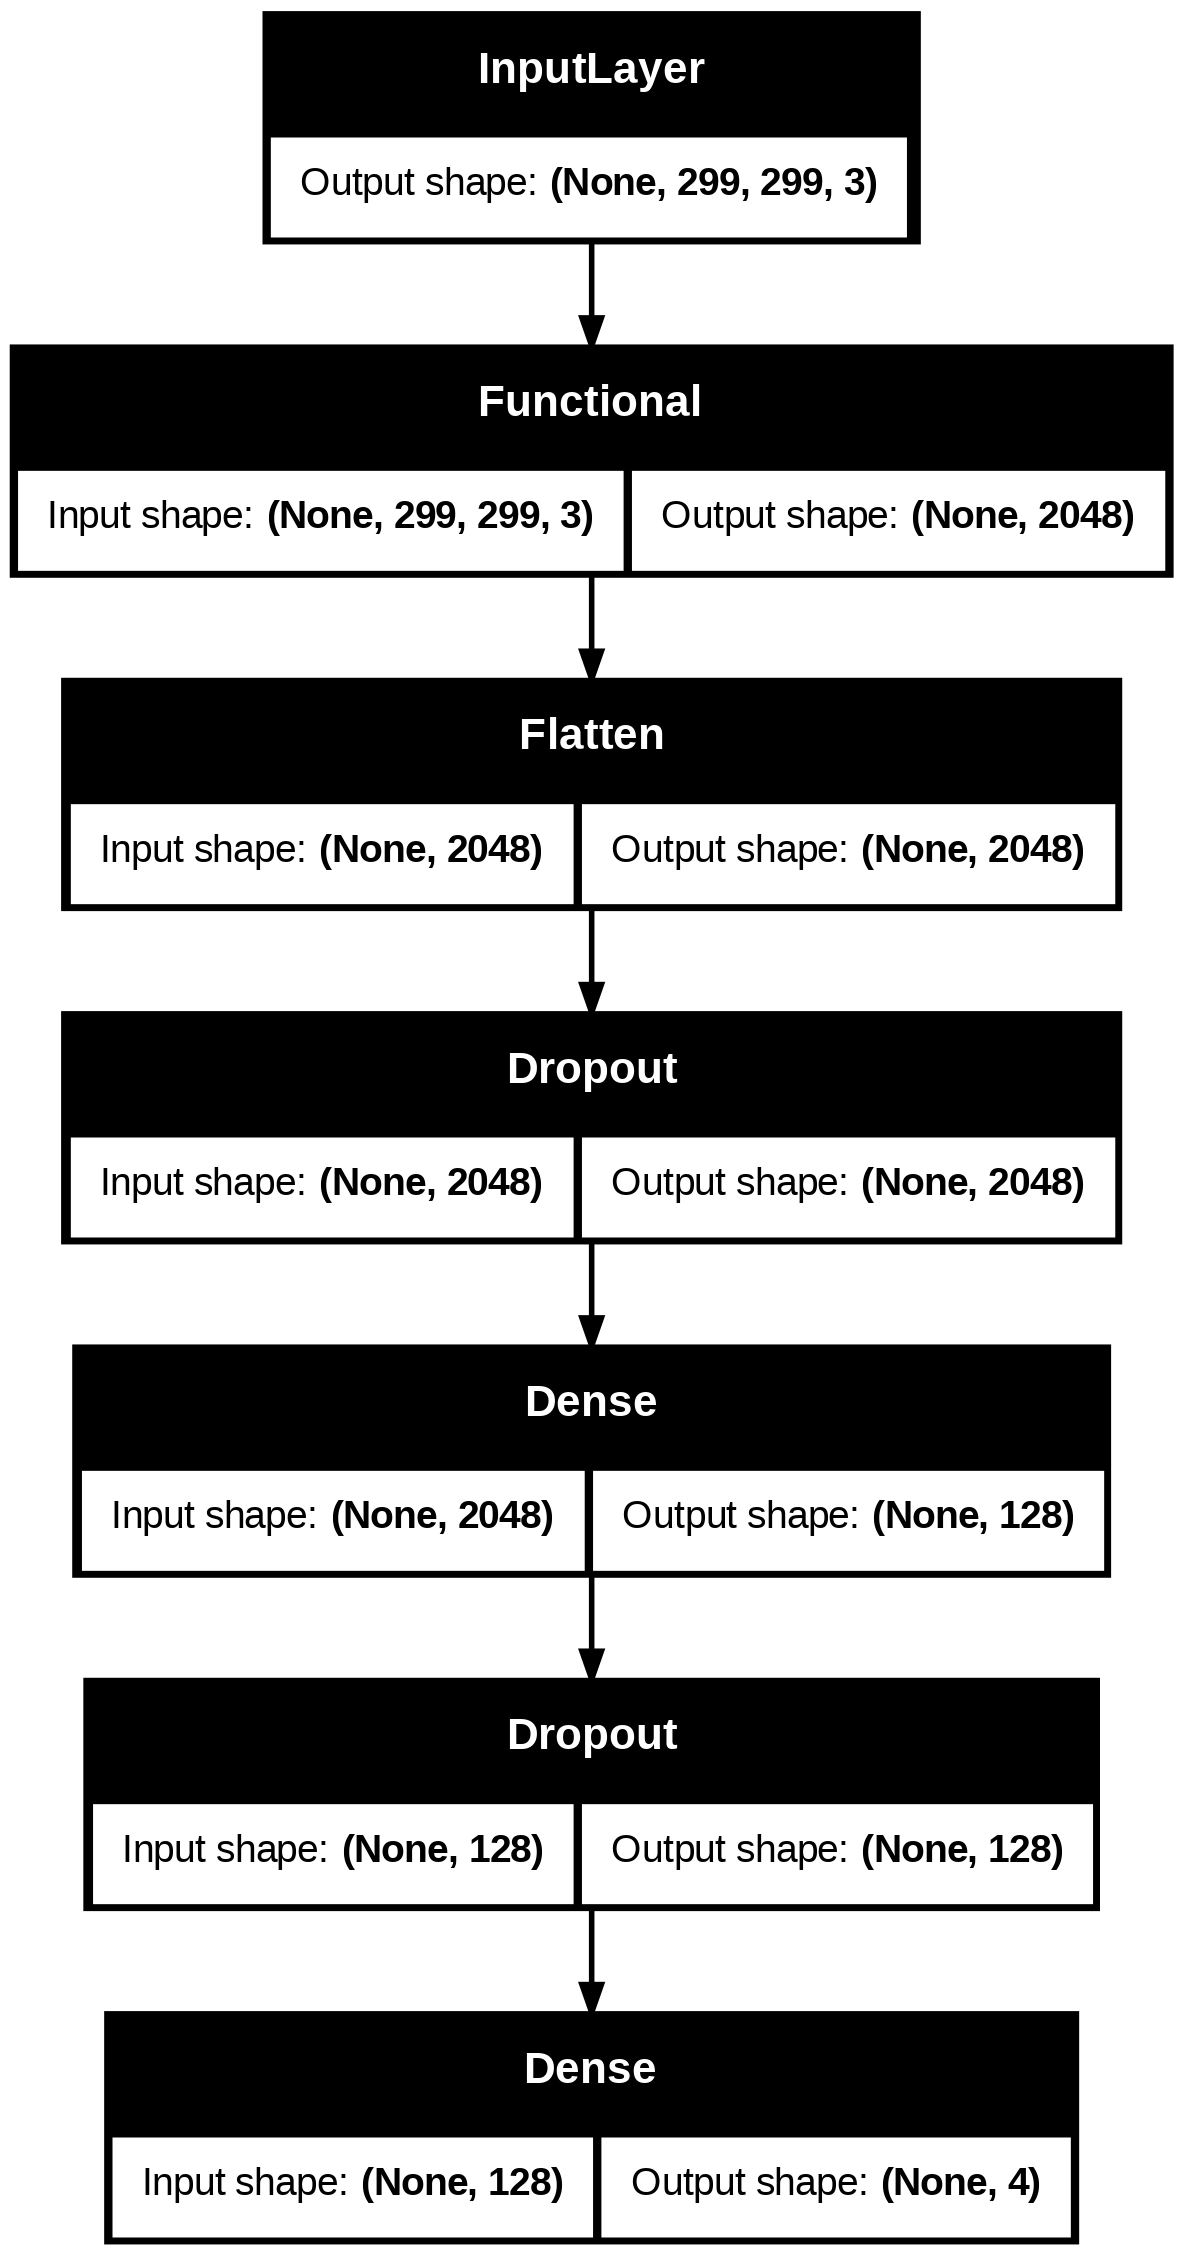

In [56]:
keras.utils.plot_model(model, show_shapes=True)

In [58]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
device_name = tf.test.gpu_device_name()
if device_name:
    print(f"Using GPU: {device_name}")
else:
    print("GPU is not available. Ensure GPU is enabled in Kaggle settings.")

# Training parameters
batch_size = 20
steps = len(train_paths) // batch_size
epochs = 20

# Callbacks for better training
checkpoint = ModelCheckpoint(
    'alzheimer_best_model.keras', save_best_only=True, monitor='val_loss', mode='min'
)
early_stopping = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

# Start training
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps,
    validation_data=datagen(test_paths, test_labels, batch_size=batch_size, epochs=epochs),
    validation_steps=len(test_paths) // batch_size,
    callbacks=[checkpoint, early_stopping]
)


Using GPU: /device:GPU:0
Epoch 1/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 95s 185ms/step - accuracy: 0.4537 - loss: 1.3323 - precision_2: 0.5611 - recall_2: 0.2658 - val_accuracy: 0.5286 - val_loss: 0.9662 - val_precision_2: 0.6412 - val_recall_2: 0.3333
Epoch 2/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 107s 209ms/step - accuracy: 0.6377 - loss: 0.8154 - precision_2: 0.7492 - recall_2: 0.4989 - val_accuracy: 0.5504 - val_loss: 0.9240 - val_precision_2: 0.6671 - val_recall_2: 0.3741
Epoch 3/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 92s 181ms/step - accuracy: 0.6756 - loss: 0.7322 - precision_2: 0.7671 - recall_2: 0.5473 - val_accuracy: 0.5449 - val_loss: 0.9076 - val_precision_2: 0.6455 - val_recall_2: 0.3963
Epoch 4/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 92s 180ms/step - accuracy: 0.6923 - loss: 0.6799 - precision_2: 0.7873 - recall_2: 0.5822 - val_accuracy: 0.5512 - val_loss: 0.8817 - val_precision_2: 0.6671 - val_recall_2: 0.3995
Epoch 5/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 92s 180ms/step - accuracy: 0.7036 - loss: 0.6513 -

In [61]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm

# Define the number of clients and the number of training rounds
NUM_CLIENTS = 10
NUM_ROUNDS = 3

# Define the clients and their data
clients = []
for i in range(NUM_CLIENTS):
    client_data = train_paths[i * (len(train_paths) // NUM_CLIENTS):(i + 1) * (len(train_paths) // NUM_CLIENTS)]
    client_labels = train_labels[i * (len(train_labels) // NUM_CLIENTS):(i + 1) * (len(train_labels) // NUM_CLIENTS)]
    clients.append((client_data, client_labels))

# Federated learning loop
for round_num in range(NUM_ROUNDS):
    print(f"\n=== Federated Learning Round {round_num + 1} / {NUM_ROUNDS} ===")

    # Select clients
    selected_client_indices = np.random.choice(len(clients), size=int(NUM_CLIENTS * 0.5), replace=False)
    selected_clients = [clients[i] for i in selected_client_indices]

    print(f"Selected Clients for Round {round_num + 1}: {selected_client_indices}")

    # Transmit the global model to the selected clients
    for client_idx, client in enumerate(selected_clients):
        print(f"\n--- Training Client {selected_client_indices[client_idx]} ---")
        
        # Clone and set global model weights
        client_model = tf.keras.models.clone_model(model)
        client_model.set_weights(model.get_weights())
        
        # Compile the client model
        client_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['categorical_accuracy']
        )
        
        steps_per_epoch = int(len(client[0]) / 20)
        
        print(f"Training Client {selected_client_indices[client_idx]} - Steps Per Epoch: {steps_per_epoch}, Epochs: 5")
        
        # Train locally
        client_model.fit(
            datagen(client[0], client[1], batch_size=batch_size, epochs=5),
            epochs=5,
            steps_per_epoch=steps_per_epoch
        )
        
        print(f"Completed Training for Client {selected_client_indices[client_idx]}")

        # Aggregate the model
        print(f"Aggregating Model for Client {selected_client_indices[client_idx]}...")
        new_weights = []
        for layer_index in range(len(model.get_weights())):
            new_layer_weights = np.mean(
                [client_model.get_weights()[layer_index], model.get_weights()[layer_index]],
                axis=0
            )
            new_weights.append(new_layer_weights)
        model.set_weights(new_weights)

    print(f"Completed Aggregation for Round {round_num + 1}")

# Evaluate the model
batch_size = 32
steps = int(len(test_paths) / batch_size)
y_pred = []
y_true = []

print("\n=== Evaluating the Model on Test Data ===")
for x, y in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps):
    pred = model.predict(x)
    pred = np.argmax(pred, axis=-1)
    for i in decode_label(pred):
        y_pred.append(i)
    for i in decode_label(y):
        y_true.append(i)

# Save the model
model.save('federated_alzhimer_model.keras')
print("\nModel saved as 'federated_model.keras'")



=== Federated Learning Round 1 / 3 ===
Selected Clients for Round 1: [2 1 9 4 6]

--- Training Client 2 ---
Training Client 2 - Steps Per Epoch: 51, Epochs: 5
Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - categorical_accuracy: 0.7710 - loss: 0.4912
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 166ms/step - categorical_accuracy: 0.7840 - loss: 0.4805
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - categorical_accuracy: 0.7745 - loss: 0.4709
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - categorical_accuracy: 0.7688 - loss: 0.4785
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - categorical_accuracy: 0.7828 - loss: 0.4780
Completed Training for Client 2
Aggregating Model for Client 2...

--- Training Client 1 ---
Training Client 1 - Steps Per Epoch: 51, Epochs: 5
Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - categorical_accuracy: 0.7464 - loss: 0.5379
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - categorical_accuracy: 0.7510 - loss: 0.5353
Epoch 3/5
51/

  0%|          | 0/39 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step


  0%|          | 0/39 [00:22<?, ?it/s]


TypeError: only integer scalar arrays can be converted to a scalar index

In [70]:
def decode_label(labels):
    # Check if labels are one-hot encoded
    if len(labels.shape) > 1:  # If more than 1D, assume one-hot
        labels = np.argmax(labels, axis=-1)
    decoded = [unique_labels[x] for x in labels]
    return decoded


In [71]:
print("\n=== Evaluating the Model on Test Data ===")
for x, y in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps):
    pred = model.predict(x)
    pred = np.argmax(pred, axis=-1)  # Predicted class indices

    # Decode predictions
    y_pred.extend(decode_label(pred))  # Extend to avoid nesting arrays

    # Decode ground truth labels
    y = np.argmax(y, axis=-1) if len(y.shape) > 1 else y  # Handle one-hot encoding
    y_true.extend(decode_label(y))


=== Evaluating the Model on Test Data ===


  0%|          | 0/39 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


  3%|▎         | 1/39 [00:00<00:21,  1.79it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


...

 97%|█████████▋| 38/39 [00:22<00:00,  1.72it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


100%|██████████| 39/39 [00:22<00:00,  1.73it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step


40it [00:47,  1.18s/it]                        


In [76]:
print(classification_report(y_true, y_pred))



                           precision    recall  f1-score  support

     Mild Impairment       0.71      0.63      0.67       179
 Moderate Impairment       0.85      0.50      0.63        12
       No Impairment       0.80      0.84      0.82       640
Very Mild Impairment       0.73      0.72      0.73       448

            accuracy                           0.77      1279
           macro avg       0.77      0.67      0.71      1279
        weighted avg       0.76      0.77      0.76      1279



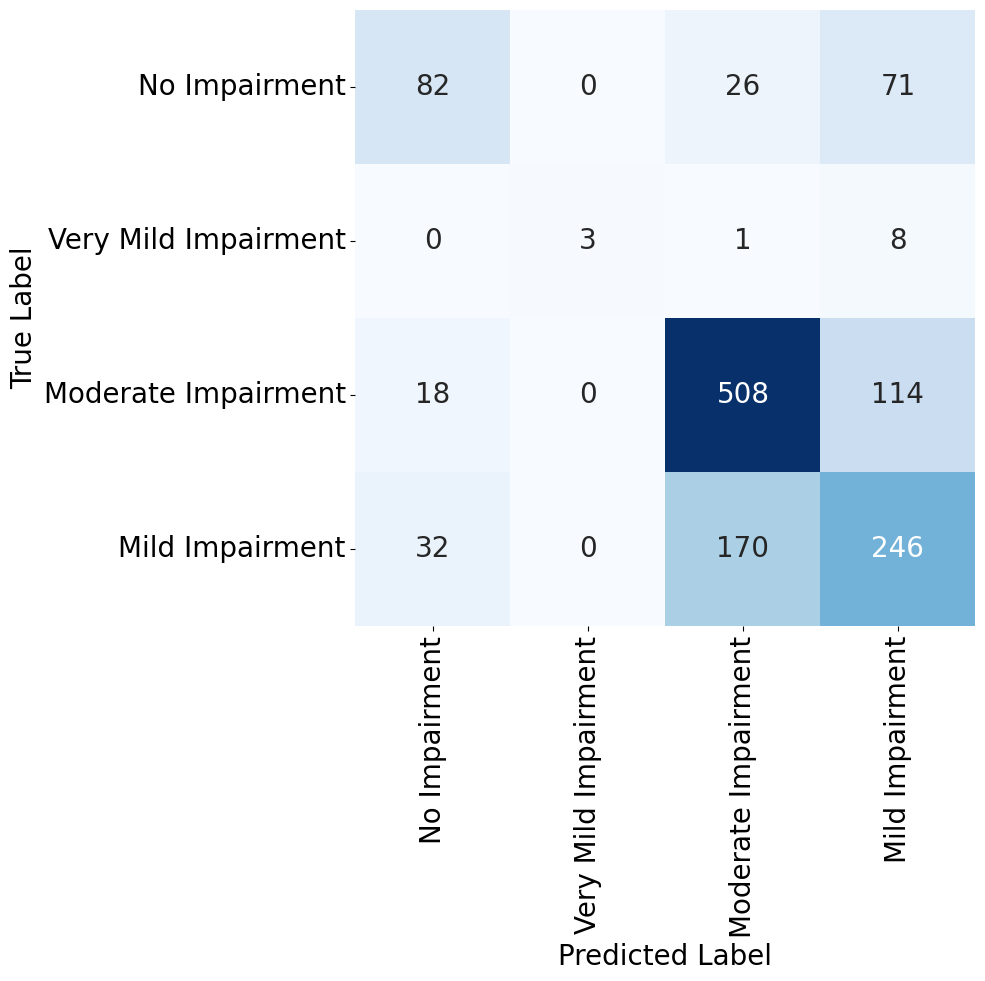

In [77]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np




cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=unique_labels, yticklabels=unique_labels, cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()


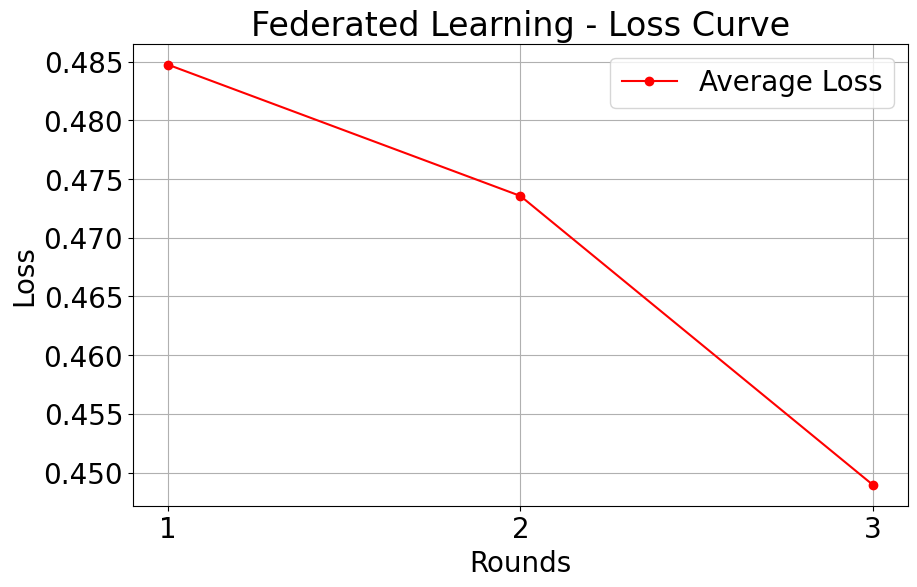

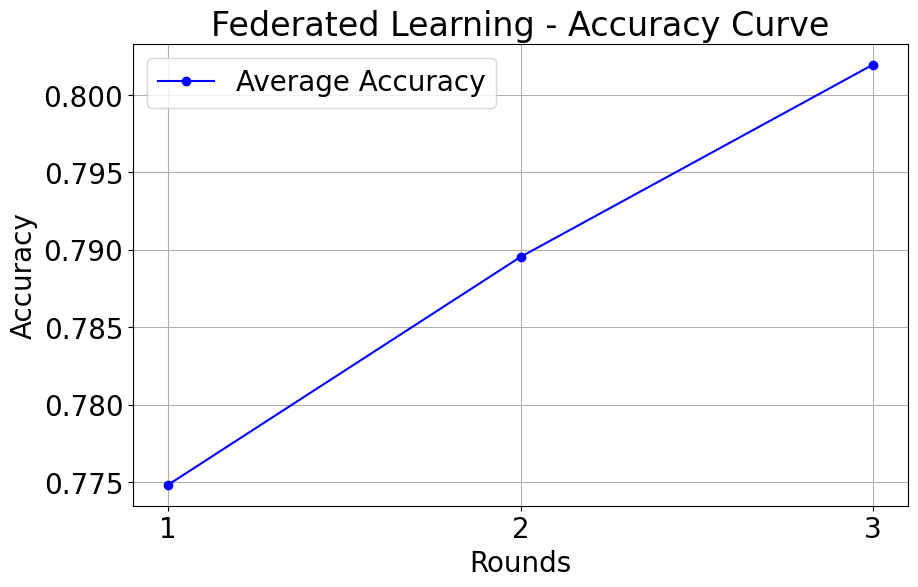

In [78]:
import matplotlib.pyplot as plt

# Extracted final loss and accuracy for each client in each round
losses_per_round = {
    1: [0.4912, 0.5379, 0.4487, 0.4934, 0.4525],  # Round 1
    2: [0.4635, 0.4726, 0.4344, 0.4688, 0.5285],  # Round 2
    3: [0.4721, 0.4420, 0.4520, 0.4270, 0.4517],  # Round 3
}
accuracies_per_round = {
    1: [0.7710, 0.7464, 0.7958, 0.7685, 0.7924],  # Round 1
    2: [0.8084, 0.7815, 0.8030, 0.7848, 0.7700],  # Round 2
    3: [0.8044, 0.8155, 0.8126, 0.8002, 0.7771],  # Round 3
}

# Calculate average loss and accuracy for each round
average_losses = [sum(losses) / len(losses) for losses in losses_per_round.values()]
average_accuracies = [sum(acc) / len(acc) for acc in accuracies_per_round.values()]

# Rounds
rounds = list(losses_per_round.keys())

# Plotting the Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(rounds, average_losses, marker='o', label='Average Loss', color='red')
plt.title('Federated Learning - Loss Curve')
plt.xlabel('Rounds')
plt.ylabel('Loss')
plt.xticks(rounds)
plt.grid(True)
plt.legend()
plt.show()

# Plotting the Accuracy Curve
plt.figure(figsize=(10, 6))
plt.plot(rounds, average_accuracies, marker='o', label='Average Accuracy', color='blue')
plt.title('Federated Learning - Accuracy Curve')
plt.xlabel('Rounds')
plt.ylabel('Accuracy')
plt.xticks(rounds)
plt.grid(True)
plt.legend()
plt.show()


In [81]:
model.save('alzimer_federated_model.keras')

In [82]:
!zip -r file.zip /kaggle/working/

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/model.png (deflated 21%)
  adding: kaggle/working/alzimer_federated_model.keras

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


 (deflated 8%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/federated_model.keras (deflated 8%)
  adding: kaggle/working/alzheimer_best_model.keras (deflated 8%)
